<a href="https://colab.research.google.com/github/gk2311/AIHC5020/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the Google Cloud Storage client if needed
!pip install -q google-cloud-storage

# Problem 1

In [2]:
import io
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import storage
from google.auth.credentials import AnonymousCredentials

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(
    project="aihc-5020"
)

In [3]:
# Anonymous credentials are sufficient because this is a public bucket
storage_client = storage.Client(
    credentials=AnonymousCredentials()
)

bucket = storage_client.bucket("cloud-samples-data")

In [4]:
blobs = storage_client.list_blobs(
    "cloud-samples-data",
    prefix="ml-engine"
)

for blob in blobs:
    if "adult.data.csv" in blob.name:
        print(blob.name)

ml-engine/census/data/adult.data.csv


In [5]:
COLUMN_NAMES = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income_bracket"
]

In [6]:
def load_csv_blob(blob_name, bucket, column_names=[]):
    blob = bucket.blob(blob_name)

    csv_data = blob.download_as_bytes()

    csv_file = io.BytesIO(csv_data)

    if column_names:
        dataframe = pd.read_csv(
            csv_file,
            names=column_names,
            skipinitialspace=True
        )
    else:
        dataframe = pd.read_csv(csv_file)

    return dataframe

In [7]:
blob_name = "ml-engine/census/data/adult.data.csv"

df = load_csv_blob(
    blob_name=blob_name,
    bucket=bucket,
    column_names=COLUMN_NAMES
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

DataFrame shape: (32561, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income_bracket']


# Problem 2

In [9]:
query = """
SELECT
    date,
    new_confirmed,
    new_deceased
FROM
    `bigquery-public-data.covid19_open_data.covid19_open_data`
WHERE
    country_name = 'Mexico'
    AND date >= '2021-01-01'
    AND date < '2022-01-01'
ORDER BY
    date ASC
"""

In [10]:
query_job = client.query(query)

In [11]:
mexico_covid_df = query_job.to_dataframe()

In [12]:
print("Number of rows:", len(df))
df.head()

Number of rows: 32561


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Problem 3

In [13]:
mexico_covid_df['date'] = pd.to_datetime(mexico_covid_df['date'])
mexico_covid_df['month'] = mexico_covid_df['date'].apply(lambda dt: dt.month)

In [14]:
monthly_covid_df = (
    mexico_covid_df
    .groupby('month')[['new_confirmed', 'new_deceased']]
    .sum()
    .reset_index()
)

monthly_covid_df

,month,new_confirmed,new_deceased
0,1,424394,39156
1,2,195234,23558
2,3,143254,13099
3,4,93647,7606
4,5,65871,4004
5,6,107135,3152
6,7,381611,8735
7,8,523222,22656
8,9,273774,16481
9,10,124864,8110


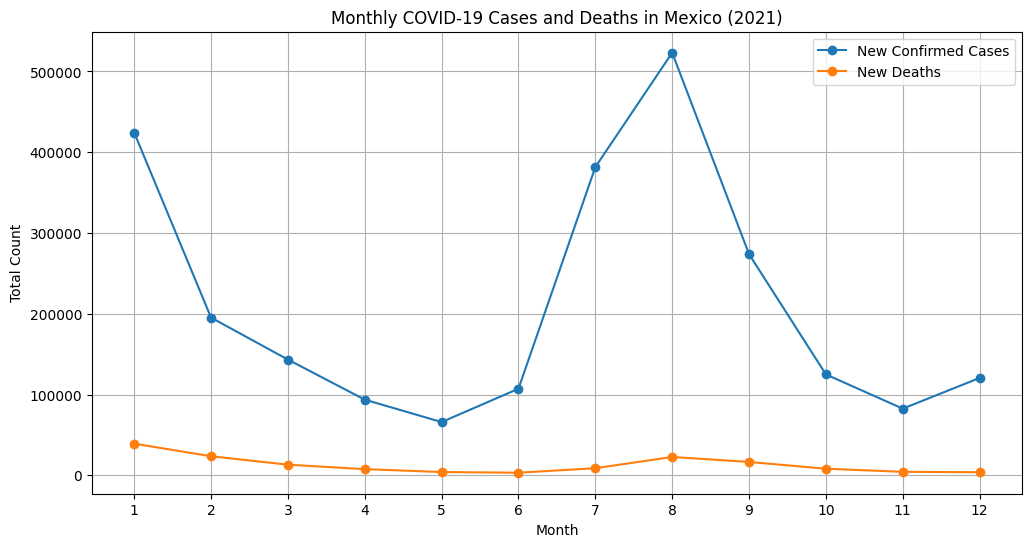

In [15]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_covid_df['month'],
    monthly_covid_df['new_confirmed'],
    marker='o',
    label='New Confirmed Cases'
)

plt.plot(
    monthly_covid_df['month'],
    monthly_covid_df['new_deceased'],
    marker='o',
    label='New Deaths'
)

plt.title('Monthly COVID-19 Cases and Deaths in Mexico (2021)')
plt.xlabel('Month')
plt.ylabel('Total Count')

plt.xticks(range(1, 13))

plt.legend()
plt.grid(True)

plt.show()

# References
- Co-Pilot to figure out why I was not able to exit the enterprise account. I ended up using my personal accoount.
